In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
tatanic_df = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
tatanic_df.head(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False


### Below I have seprated the input DataFrame and Output column (prediction)

In [4]:
input_columns = tatanic_df.columns[1:-2].to_list()
output_column = tatanic_df.columns[-1]

In [5]:
input_df, target_col = tatanic_df[input_columns], tatanic_df[output_column]

In [6]:
print(input_df.shape)
input_df.describe()

(8693, 11)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


### Seprating numeric and categoric column will help us perform EDA better

In [7]:
numeric_cols = input_df.select_dtypes(include=np.number).columns.to_list()
categoric_cols = input_df.select_dtypes(include='object').columns.to_list()

In [8]:
input_df[numeric_cols].isna().mean() * 100

Age             2.059128
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
dtype: float64

#### Above we can see that the numeric columns has nan values which needs to be addressed, because this will cause a decrease in accuracy while predicting.

In [9]:
list(enumerate(numeric_cols))

[(0, 'Age'),
 (1, 'RoomService'),
 (2, 'FoodCourt'),
 (3, 'ShoppingMall'),
 (4, 'Spa'),
 (5, 'VRDeck')]

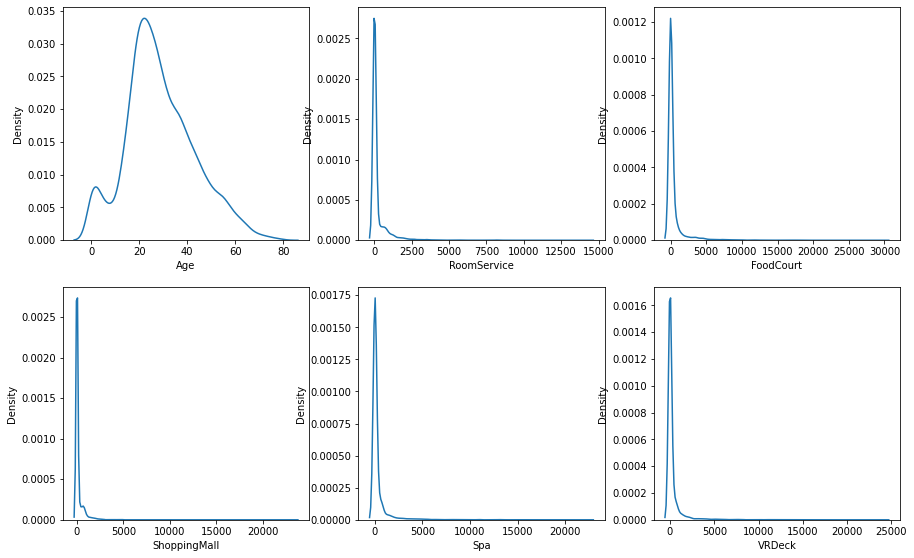

In [10]:
plt.figure(figsize = (15, 30))
for i in enumerate(numeric_cols):
    plt.subplot(6, 3, i[0] + 1)
    sns.kdeplot(i[1], data=input_df)



## From the above plot its visible that almost all the columns are right skewed. Which means ideally inducing the nan values with the columns median would be better than the columns mean

Below function is to train numeric columns and convert it into a dataframe which can be fed to an Sklearn algorithm for predicting Output.¶
The function perform tasks such as:

* Imputing nan values
* Scaling numeric columns

In [11]:
def preprocess_numeric_data(df, columns):

    ## Replacing nan values

    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    
    imputer = imputer.fit(df[columns])
    df[columns] = imputer.transform(df[columns])

    ## Scaling Data

    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()

    scaler = scaler.fit(df[columns])
    df[columns] = scaler.transform(df[columns])

    return df, imputer, scaler

### Below function is to train categoric columns and convert it into a dataframe which can be fed to an Sklearn algorithm for predicting Output. 

#### The function perform tasks such as:
* Imputing nan values
* Encoding categoric data

In [12]:
def preprocess_categoirc_data(df, columns):

    ## EDA

    df['Cabin'] = df['Cabin'].apply(lambda x: str(x).split("/")[0])

    ## Replacing nan values

    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='most_frequent')

    imputer = imputer.fit(df[columns])
    df[columns] = imputer.transform(df[columns])

    ## Encoding Categoric Columns

    from sklearn.preprocessing import OneHotEncoder
    ohe = OneHotEncoder(sparse=False, drop='first', dtype=np.int64)

    ohe = ohe.fit(df[columns])
    ohe_features = ohe.get_feature_names(columns)
    df[ohe_features] = ohe.transform(df[columns])

    return df, imputer, ohe, ohe_features

In [13]:
input_df, numeric_imputer, numeric_scaler = preprocess_numeric_data(input_df, numeric_cols)

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


In [14]:
input_df, categoric_imputer, categoric_encoder, encoder_features = preprocess_categoirc_data(input_df, categoric_cols)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(m

### Since the target column: "Transported" has True and False as its values, it is essential to encode it, which is why we use Label encoder, as it is advisable by Sklearn to use Label encoder over OneHotEncoder or Ordinal Encoder.

In [15]:
## Encoding of Output Columns - (Y)

from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

label = label.fit(target_col)

target_col = label.transform(target_col)
target_col = pd.Series(target_col)

In [16]:
temp_input = input_df[numeric_cols + encoder_features.tolist()]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(temp_input, target_col, test_size=0.2, random_state=42)

In [18]:
X_train.head(3)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_nan,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
2333,-0.055109,-0.333105,-0.246559,-0.283579,0.312227,-0.263003,0,0,0,0,0,0,0,0,0,0,1,0,1,0
2589,-0.822163,-0.333105,0.467861,-0.231737,-0.270626,-0.263003,0,0,0,0,0,0,0,1,0,0,0,0,1,0
8302,-0.055109,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,1,0,1,0,1,0,0,0,0,0,0,0,0,0


In [19]:
X_train.shape

(6954, 20)

## Below I have used a simple DecisionTreeClassifier to check the accuracy.

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score
score1 = accuracy_score(y_test, y_pred)

### Further using A randomForestClassifier is used, and the hyperparameters are selected basis of GridSearchCV and the accuracy in this case certainly increased.

In [22]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=400, bootstrap=True,criterion='entropy', min_samples_split=120, max_features=5, 
max_depth=None, n_jobs=-1, max_leaf_nodes=60)

In [23]:
rfc.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_features=5, max_leaf_nodes=60,
                       min_samples_split=120, n_estimators=400, n_jobs=-1)

In [24]:
y_pred = rfc.predict(X_test)
score2 = accuracy_score(y_test, y_pred)

### finally using XGBoost as the third algorithm to check if it provides a better acccuracy. Refer below for the comparism.

In [25]:
import xgboost as xgb

In [26]:
xgb_classifier = xgb.XGBClassifier(booster= 'gbtree', gamma= 0, learning_rate= 0.05, max_depth= 4, n_estimators= 500, reg_alpha= 0, reg_lambda= 0)
xgb_classifier.fit(X_train,y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.05, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=4, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=500,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=0, ...)

In [27]:
y_pred = xgb_classifier.predict(X_test)

In [28]:
score3 = accuracy_score(y_test, y_pred)

In [29]:
print("DecisionTreeClassifier has an accuracy of {0}\nRandomForestClassifier has an accuracy of {1}\nXGBoost has an accuracy of {2}".format(score1*100, score2*100, score3*100))

DecisionTreeClassifier has an accuracy of 74.00805060379528
RandomForestClassifier has an accuracy of 79.29844738355378
XGBoost has an accuracy of 79.06843013225992


In [30]:
testing_df = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
testing_df.head(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False


In [31]:
test_input_cols = testing_df.columns[1:-2]

test_input_df = testing_df[test_input_cols]

In [32]:
test_numeric_cols = test_input_df.select_dtypes(include=np.number).columns.to_list()
test_categotic_cols = test_input_df.select_dtypes(include='object').columns.to_list()
test_numeric_cols

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

### Transforming numeric test data as per train data

In [33]:
def transform_numeric_data(df, columns, imputer, scaler):

    df[columns] = imputer.transform(df[columns])
    df[columns] = scaler.transform(df[columns])

    return df

### Transforming categoric test data as per train data

In [34]:
def transform_categoric_data(df, columns, imputer, encoder, encoder_features):

    df['Cabin'] = df['Cabin'].apply(lambda x: str(x).split('/')[0])
    df[columns] = imputer.transform(df[columns])
    df[encoder_features] = encoder.transform(df[columns])

    return df

In [35]:
test_numeric_df = transform_numeric_data(test_input_df, test_numeric_cols, numeric_imputer, numeric_scaler)

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


In [36]:
test_categotic_cols, categoric_cols

(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP'],
 ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP'])

In [37]:
test_categoric_df = transform_categoric_data(test_input_df, test_categotic_cols, categoric_imputer, categoric_encoder, encoder_features)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

In [38]:
y_pred = rfc.predict(test_input_df[test_numeric_cols + encoder_features.tolist()])

In [39]:
output = pd.DataFrame({'PassengerId': testing_df.PassengerId, 'Transported': y_pred})

In [40]:
output['Transported'] = output['Transported'].apply(lambda x: True if int(x) == 1 else False)

### Finally I have predicted the output and saved the output in the column Transported in DataFrame output and saved the output in a csv names Submission.csv

In [41]:
output.to_csv('submission.csv', index = False)

In [42]:
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [43]:
print("Thanks !")

Thanks !


In [44]:
print("Thanks !")

Thanks !
